# Which Products Break First?
## A Fragility-Based View of Retail Supply Chains

$$
\text{Demand} \rightarrow \text{Fragility} \rightarrow \text{Risk} \rightarrow \text{Decision} \rightarrow \text{Resilience}
$$

## Introduction

Retail analytics is often framed as a demand forecasting problem.  
That framing is useful, but increasingly incomplete.

In a world shaped by geopolitical tension, logistics disruption, inflationary pressure, and sudden demand shifts, the real operational question is no longer only **how much demand will occur**. A more important question is:

**Which products become vulnerable when the system is stressed?**

This matters especially for economies such as Japan, where business activity depends heavily on global trade, imported energy, imported components, and cross-border supply chains. In such an environment, a product can fail not only because demand changes, but because the supply side becomes fragile. Forecast accuracy alone does not fully protect firms from this risk.

This notebook therefore reframes retail time-series analysis as a **fragility and resilience** problem.

Instead of stopping at demand prediction, it builds a practical framework around four operational ideas:

1. **Demand volatility** — unstable demand makes planning harder.  
2. **Order gap** — when orders fail to keep up with actual demand, disruption risk rises.  
3. **Inventory cover** — buffer inventory can absorb shocks and reduce vulnerability.  
4. **Shock exposure** — external stressors such as weather disruption, epidemic pressure, promotions, and scenario-based geopolitical shock proxies can amplify fragility.

These elements are combined into a **Supply Chain Fragility Score**, which serves as an operational risk signal rather than a pure statistical target. The objective is not to estimate an abstract probability in isolation, but to identify vulnerable store–product combinations that may require intervention.

This is important because supply chain decisions are managerial decisions.  
Managers do not act on demand curves alone. They act on:
- which SKUs deserve protection,
- which categories require more buffer,
- which items should be redesigned or sourced differently,
- and which products remain resilient even under stress.

To support this perspective, the notebook goes beyond standard exploratory analysis and includes:

- time-series feature engineering with lag and rolling statistics,
- a fragility score combining operational and external risk drivers,
- a LightGBM model to classify high-fragility observations,
- SHAP-based interpretation for actionable insight,
- a portfolio decision map linking fragility to revenue importance,
- and a stress simulation that approximates how vulnerability changes under a stronger shock scenario.

In that sense, the notebook is not just about prediction.

It is about **decision intelligence for resilience**.

The central idea is simple:

**Forecasting tells us what may happen.  
Fragility analysis tells us where the system can break.**

That shift — from prediction to resilience — is what makes this analysis more relevant for real-world supply chains, especially under geopolitical uncertainty.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (8, 5)



## Load Data

In [2]:

# Kaggle example:

df = pd.read_csv('/kaggle/input/datasets/raminhuseyn/demand-forecasting-dataset/demand_forecasting.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
display(df.head())
display(df.describe(include='all').T)


(76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,76000,NaN,NaN,NaN,2023-01-15 12:00:00,2022-01-01 00:00:00,2022-07-09 18:00:00,2023-01-15 12:00:00,2023-07-24 06:00:00,2024-01-30 00:00:00,NaN
Store ID,76000,5,S001,15200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,76000,20,P0001,3800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,76000,5,Groceries,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,76000,4,North,30400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inventory Level,76000.0,NaN,NaN,NaN,301.062842,0.0,136.0,227.0,408.0,2267.0,226.510161
Units Sold,76000.0,NaN,NaN,NaN,88.827316,0.0,58.0,84.0,114.0,426.0,43.994525
Units Ordered,76000.0,NaN,NaN,NaN,89.090645,0.0,0.0,0.0,121.0,1616.0,162.404627
Price,76000.0,NaN,NaN,NaN,67.726028,4.74,31.9975,64.5,95.83,228.03,39.377899
Discount,76000.0,NaN,NaN,NaN,9.087039,0.0,5.0,10.0,10.0,25.0,7.475781



## Quick Data Overview


Date range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00
Stores: 5
Products: 20
Categories: 5
Regions: 4


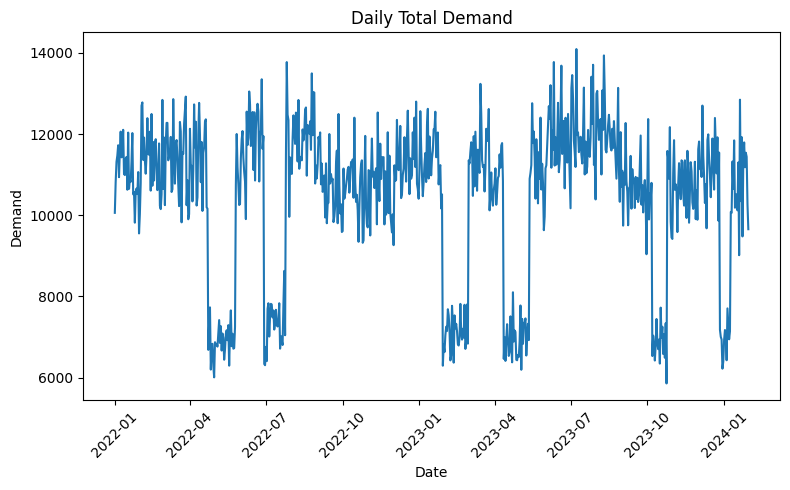

In [3]:

print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Stores:", df['Store ID'].nunique())
print("Products:", df['Product ID'].nunique())
print("Categories:", df['Category'].nunique())
print("Regions:", df['Region'].nunique())

daily_demand = df.groupby('Date', as_index=False)['Demand'].sum()

plt.figure()
plt.plot(daily_demand['Date'], daily_demand['Demand'])
plt.title('Daily Total Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Time-Series Feature Engineering

I construct lag and rolling features at the store–product level to capture recent dynamics and inventory stress.


In [4]:

df = df.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)
grp = df.groupby(['Store ID', 'Product ID'], sort=False)

for col in ['Demand', 'Units Sold', 'Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Competitor Pricing']:
    cname = col.lower().replace(' ', '_')
    df[f'{cname}_lag1'] = grp[col].shift(1)

df['demand_roll7_mean'] = grp['Demand'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df['demand_roll30_mean'] = grp['Demand'].transform(lambda s: s.shift(1).rolling(30, min_periods=7).mean())
df['demand_roll30_std'] = grp['Demand'].transform(lambda s: s.shift(1).rolling(30, min_periods=7).std())
df['units_sold_roll7_mean'] = grp['Units Sold'].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())

df['inventory_cover_days'] = (df['Inventory Level'] / df['units_sold_roll7_mean'].replace(0, np.nan)).clip(0, 60)
df['order_gap_ratio'] = ((df['Demand'] - df['Units Ordered']) / df['Demand'].replace(0, np.nan)).clip(-2, 2)
df['stockout_flag'] = (df['Units Sold'] < df['Demand']).astype(int)

df['month'] = df['Date'].dt.month
df['dayofweek'] = df['Date'].dt.dayofweek
df['dayofyear'] = df['Date'].dt.dayofyear
df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)



## Shock Proxies

The dataset does not contain a direct geopolitical variable.  
So we create a **scenario-style stress proxy** using:
- a date-based geopolitical stress window,
- weather disruption,
- epidemic pressure,
- and promotional intensity.

This is not a claim about historical truth inside the dataset.  
It is a decision-oriented stress simulation.


In [5]:

df['geo_shock'] = ((df['Date'] >= '2023-10-01') & (df['Date'] <= '2023-12-15')).astype(int)
df['weather_risk'] = df['Weather Condition'].isin(['Stormy', 'Snowy']).astype(int)
df['epidemic_risk'] = df['Epidemic'].astype(int)
df['promo_intensity'] = df['Promotion'] * (1 + df['Discount'] / 100.0)

import_dependency_map = {
    'Electronics': 0.90,
    'Clothing': 0.65,
    'Furniture': 0.60,
    'Toys': 0.55,
    'Groceries': 0.35,
}
df['import_dependency'] = df['Category'].map(import_dependency_map).fillna(0.50)

df['shock_exposure'] = (
    0.45 * df['geo_shock'] * df['import_dependency']
    + 0.25 * df['weather_risk']
    + 0.20 * df['epidemic_risk']
    + 0.10 * (df['promo_intensity'] > 1.10).astype(int)
)

display(df[['Category', 'geo_shock', 'weather_risk', 'epidemic_risk', 'promo_intensity', 'import_dependency', 'shock_exposure']].head())


,Category,geo_shock,weather_risk,epidemic_risk,promo_intensity,import_dependency,shock_exposure
0,Electronics,0,1,0,0.00,0.9,0.25
1,Electronics,0,1,0,0.00,0.9,0.25
2,Electronics,0,1,0,1.15,0.9,0.35
3,Electronics,0,1,0,0.00,0.9,0.25
4,Electronics,0,1,0,1.25,0.9,0.35



## Build the Fragility Score

$$
\text{Fragility Score}
=
0.35 \cdot \text{Demand Volatility}
+
0.25 \cdot \text{Order Gap}
+
0.20 \cdot \text{Shock Exposure}
-
0.20 \cdot \text{Inventory Cover}
$$

This score is designed to reflect operational vulnerability rather than pure demand intensity.


In [6]:

for c in ['demand_roll7_mean', 'demand_roll30_mean', 'demand_roll30_std', 'units_sold_roll7_mean', 'inventory_cover_days', 'order_gap_ratio']:
    df[c] = df[c].fillna(df[c].median())

def zscore(s):
    std = s.std(ddof=0)
    if std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

df['fragility_score'] = (
    0.35 * zscore(df['demand_roll30_std']).clip(-3, 3)
    + 0.25 * zscore(df['order_gap_ratio']).clip(-3, 3)
    + 0.20 * zscore(df['shock_exposure']).clip(-3, 3)
    - 0.20 * zscore(df['inventory_cover_days']).clip(-3, 3)
)

fragility_threshold = df['fragility_score'].quantile(0.80)
df['fragility_target'] = ((df['fragility_score'] >= fragility_threshold) | (df['stockout_flag'] == 1)).astype(int)

print('Fragility threshold:', round(fragility_threshold, 4))
print('Positive class ratio:', round(df['fragility_target'].mean(), 4))
display(df[['fragility_score', 'fragility_target']].describe())


Fragility threshold: 0.4156
Positive class ratio: 0.7604


,fragility_score,fragility_target
count,76000.000000,76000.000000
mean,0.001324,0.760434
std,0.488177,0.426821
min,-2.210629,0.000000
25%,-0.309645,1.000000
50%,0.017213,1.000000
75%,0.337621,1.000000
max,1.875226,1.000000



## Which Categories Look Most Fragile?


,Category,mean_fragility,stockout_rate,avg_inventory_cover,avg_order_gap
3,Groceries,0.188031,0.707138,3.578359,0.370038
4,Toys,0.029987,0.705545,3.341685,0.320095
0,Clothing,0.024324,0.725822,3.013378,0.345926
1,Electronics,-0.069620,0.705044,3.623805,0.371608
2,Furniture,-0.409020,0.671053,4.128506,0.367940


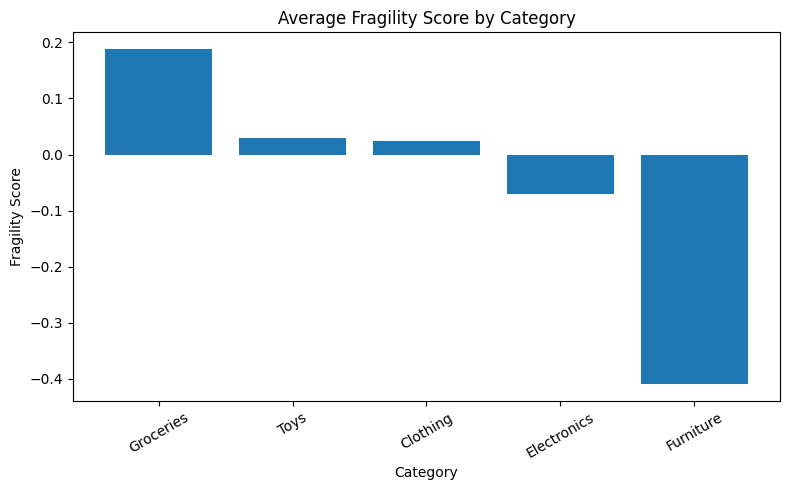

In [7]:

fragility_by_category = (
    df.groupby('Category', as_index=False)
      .agg(
          mean_fragility=('fragility_score', 'mean'),
          stockout_rate=('stockout_flag', 'mean'),
          avg_inventory_cover=('inventory_cover_days', 'mean'),
          avg_order_gap=('order_gap_ratio', 'mean')
      )
      .sort_values('mean_fragility', ascending=False)
)

display(fragility_by_category)

plt.figure()
plt.bar(fragility_by_category['Category'], fragility_by_category['mean_fragility'])
plt.title('Average Fragility Score by Category')
plt.xlabel('Category')
plt.ylabel('Fragility Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



## Model High-Fragility Risk

I use a time-based split to avoid leakage from future observations.


In [8]:

split_date = df['Date'].quantile(0.80)
train_df = df[df['Date'] < split_date].copy()
test_df = df[df['Date'] >= split_date].copy()

feature_cols = [
    'Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Promotion',
    'Competitor Pricing', 'Epidemic',
    'demand_lag1', 'units_sold_lag1', 'inventory_level_lag1',
    'units_ordered_lag1', 'price_lag1', 'discount_lag1',
    'competitor_pricing_lag1', 'demand_roll7_mean', 'demand_roll30_mean',
    'demand_roll30_std', 'units_sold_roll7_mean', 'inventory_cover_days',
    'order_gap_ratio', 'shock_exposure', 'geo_shock', 'weather_risk',
    'epidemic_risk', 'promo_intensity', 'import_dependency',
    'month', 'dayofweek', 'dayofyear', 'weekofyear',
    'is_month_start', 'is_month_end'
]
feature_cols = [c for c in feature_cols if c in df.columns]

train_df = train_df.dropna(subset=feature_cols + ['fragility_target'])
test_df = test_df.dropna(subset=feature_cols + ['fragility_target'])

X_train = train_df[feature_cols]
y_train = train_df['fragility_target']
X_test = test_df[feature_cols]
y_test = test_df['fragility_target']

model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced',
    objective='binary',
    verbose=-1
)

model.fit(X_train, y_train)

test_pred = model.predict_proba(X_test)[:, 1]
test_label = (test_pred >= 0.50).astype(int)

print('ROC-AUC :', round(roc_auc_score(y_test, test_pred), 4))
print('PR-AUC  :', round(average_precision_score(y_test, test_pred), 4))
print(classification_report(y_test, test_label, digits=4))
print('Confusion matrix:')
print(confusion_matrix(y_test, test_label))


ROC-AUC : 0.7345
PR-AUC  : 0.9211
              precision    recall  f1-score   support

           0     0.3523    0.7964    0.4885      3340
           1     0.9111    0.5877    0.7145     11860

    accuracy                         0.6336     15200
   macro avg     0.6317    0.6920    0.6015     15200
weighted avg     0.7883    0.6336    0.6648     15200

Confusion matrix:
[[2660  680]
 [4890 6970]]



## Feature Importance


,feature,importance
16,demand_roll30_std,744
18,inventory_cover_days,729
1,Units Ordered,547
0,Inventory Level,539
19,order_gap_ratio,490
15,demand_roll30_mean,349
8,units_sold_lag1,338
17,units_sold_roll7_mean,332
9,inventory_level_lag1,330
7,demand_lag1,323


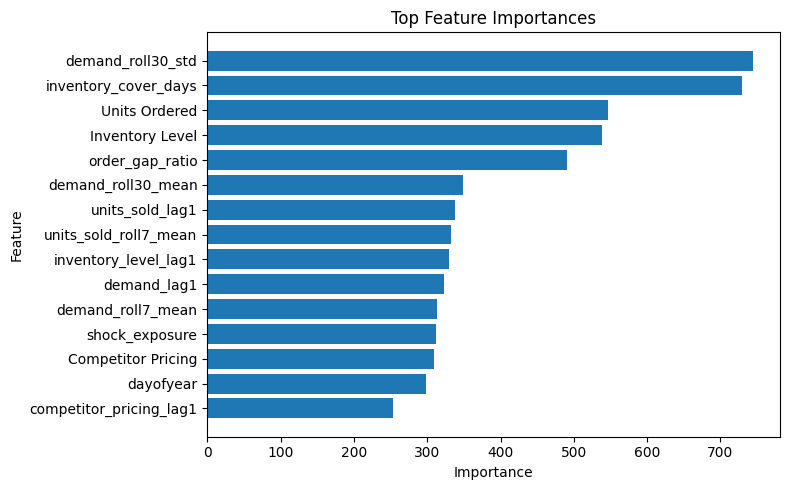

In [9]:

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(20))

plt.figure()
plot_df = importance_df.head(15).sort_values('importance')
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



## SHAP Interpretation


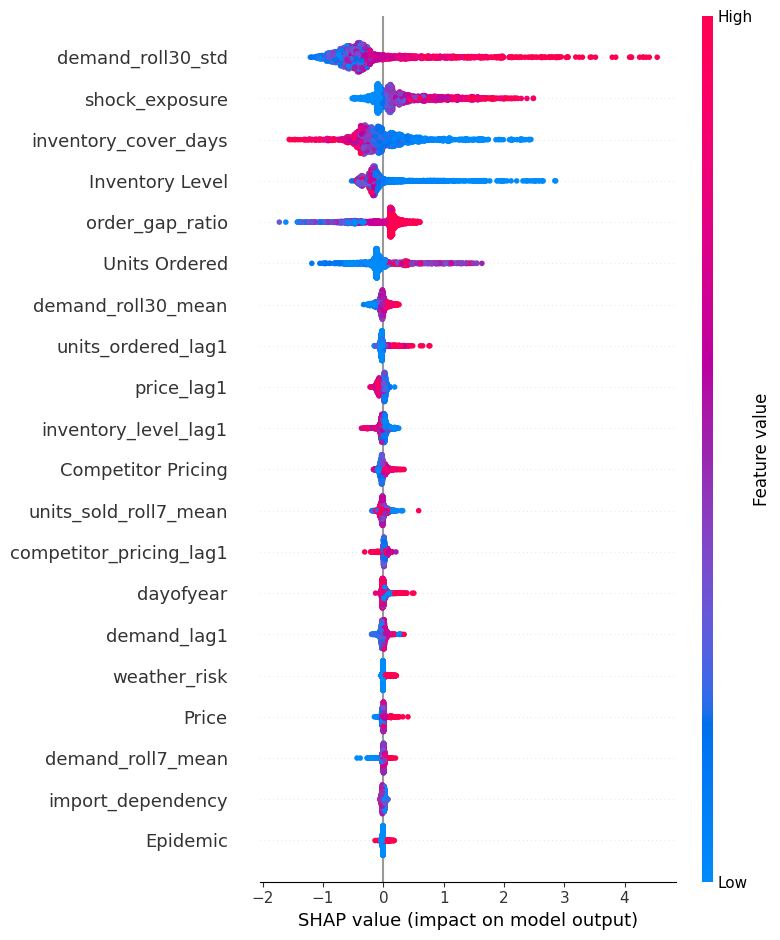

In [10]:

if SHAP_AVAILABLE:
    sample_n = min(2000, len(X_test))
    X_shap = X_test.sample(sample_n, random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap)
    shap_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(shap_to_plot, X_shap, show=True)
else:
    print("SHAP is not available in this environment.")



## Portfolio Decision Map

This section connects model output to management action.


,Store ID,Product ID,fragility_probability,avg_fragility_score,stockout_rate,avg_demand,avg_units_sold,avg_price,avg_inventory_cover,revenue_proxy,decision_quadrant
97,S005,P0018,0.805869,0.375225,0.814229,122.544137,93.571805,22.111805,1.479919,2069.041506,Rationalise / redesign
48,S003,P0009,0.797165,0.347248,0.827404,121.177866,91.914361,54.440474,1.456390,5003.861409,Rationalise / redesign
29,S002,P0010,0.780773,0.348390,0.782609,122.628458,97.368906,89.369486,1.501362,8701.809139,Protect aggressively
87,S005,P0008,0.772816,0.361278,0.795784,122.399209,98.324111,63.087905,1.531473,6203.062167,Protect aggressively
27,S002,P0008,0.759915,0.313951,0.777339,121.624506,96.806324,25.869038,1.473106,2504.286497,Rationalise / redesign
58,S003,P0019,0.741973,0.316070,0.770751,122.050066,98.009223,55.651989,1.540082,5454.408227,Rationalise / redesign
49,S003,P0010,0.736666,0.307883,0.766798,121.068511,98.636364,39.206258,1.540122,3867.162744,Rationalise / redesign
1,S001,P0002,0.724691,0.313665,0.778656,124.505929,100.309618,67.086416,1.544169,6729.412790,Protect aggressively
17,S001,P0018,0.722008,0.326482,0.723320,121.978920,103.243742,61.127523,1.688998,6311.034205,Protect aggressively
16,S001,P0017,0.710490,0.160880,0.786561,94.187088,72.517787,21.029433,1.651620,1525.007968,Rationalise / redesign


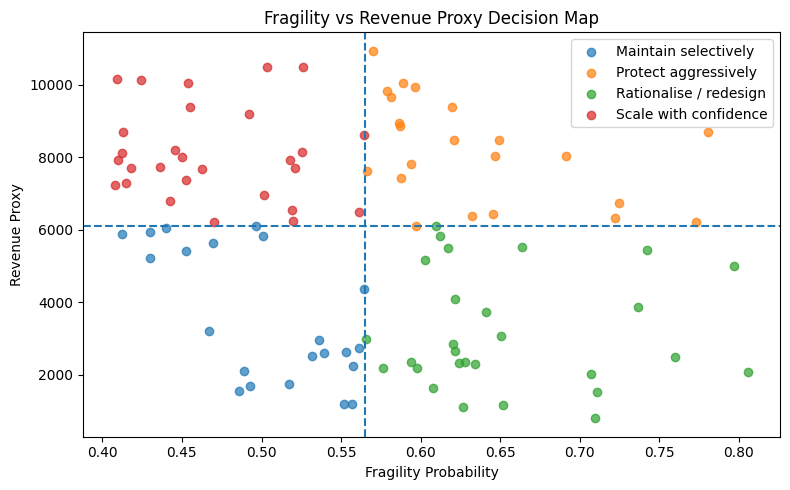

In [11]:

df_model = df.dropna(subset=feature_cols).copy()
df_model['fragility_probability'] = model.predict_proba(df_model[feature_cols])[:, 1]

portfolio = (
    df_model.groupby(['Store ID', 'Product ID'], as_index=False)
      .agg(
          fragility_probability=('fragility_probability', 'mean'),
          avg_fragility_score=('fragility_score', 'mean'),
          stockout_rate=('stockout_flag', 'mean'),
          avg_demand=('Demand', 'mean'),
          avg_units_sold=('Units Sold', 'mean'),
          avg_price=('Price', 'mean'),
          avg_inventory_cover=('inventory_cover_days', 'mean')
      )
)

portfolio['revenue_proxy'] = portfolio['avg_units_sold'] * portfolio['avg_price']

portfolio['decision_quadrant'] = np.select(
    [
        (portfolio['fragility_probability'] >= portfolio['fragility_probability'].median()) &
        (portfolio['revenue_proxy'] >= portfolio['revenue_proxy'].median()),

        (portfolio['fragility_probability'] >= portfolio['fragility_probability'].median()) &
        (portfolio['revenue_proxy'] < portfolio['revenue_proxy'].median()),

        (portfolio['fragility_probability'] < portfolio['fragility_probability'].median()) &
        (portfolio['revenue_proxy'] >= portfolio['revenue_proxy'].median())
    ],
    [
        'Protect aggressively',
        'Rationalise / redesign',
        'Scale with confidence'
    ],
    default='Maintain selectively'
)

display(portfolio.sort_values('fragility_probability', ascending=False).head(20))

plt.figure()
for label, part in portfolio.groupby('decision_quadrant'):
    plt.scatter(part['fragility_probability'], part['revenue_proxy'], alpha=0.7, label=label)

plt.axvline(portfolio['fragility_probability'].median(), linestyle='--')
plt.axhline(portfolio['revenue_proxy'].median(), linestyle='--')
plt.title('Fragility vs Revenue Proxy Decision Map')
plt.xlabel('Fragility Probability')
plt.ylabel('Revenue Proxy')
plt.legend()
plt.tight_layout()
plt.show()



## Shock Scenario Simulation

Now I simulate a more severe disruption scenario by increasing shock exposure and slightly reducing effective inventory cover.


,Store ID,Product ID,base_fragility_prob,shock_fragility_prob,delta_fragility,avg_demand,avg_price,impact_proxy
30,S002,P0011,0.581179,0.661428,0.080249,119.341238,94.975758,909.586609
8,S001,P0009,0.619981,0.698525,0.078545,121.722003,90.344730,863.749521
88,S005,P0009,0.596669,0.666294,0.069625,120.695652,95.850487,805.474941
20,S002,P0001,0.564289,0.644449,0.080159,120.923584,81.107747,786.190877
50,S003,P0011,0.570314,0.630273,0.059959,106.882740,119.757470,767.473778
76,S004,P0017,0.586279,0.658598,0.072319,110.342556,95.227457,759.903602
11,S001,P0012,0.621015,0.696538,0.075524,119.997365,82.713794,749.604268
22,S002,P0003,0.525159,0.600452,0.075293,118.358366,80.318564,715.761863
42,S003,P0003,0.691234,0.764107,0.072873,110.500659,87.912108,707.910148
47,S003,P0008,0.525830,0.582912,0.057082,109.279315,112.518155,701.872079


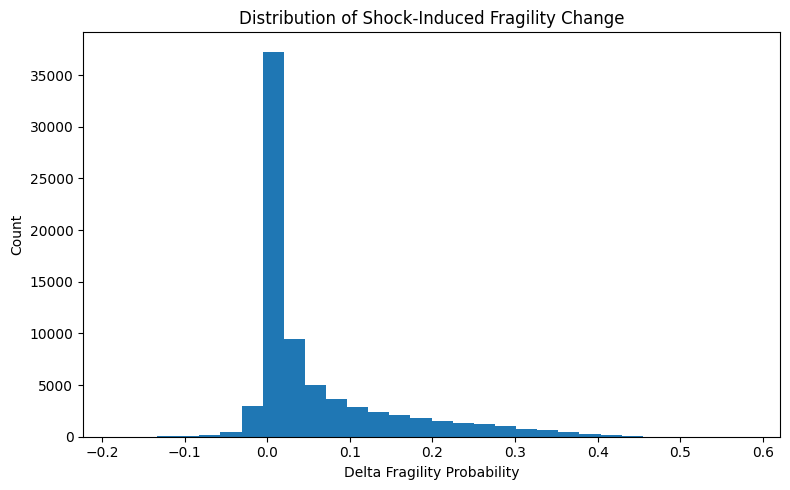

In [12]:

simulation_df = df_model.copy()

base_pred = model.predict_proba(simulation_df[feature_cols])[:, 1]

shock_df = simulation_df.copy()
shock_df['shock_exposure'] = shock_df['shock_exposure'] * 1.35 + 0.10
shock_df['geo_shock'] = 1
shock_df['inventory_cover_days'] = (shock_df['inventory_cover_days'] * 0.90).clip(lower=0)

shock_pred = model.predict_proba(shock_df[feature_cols])[:, 1]

simulation_df['base_fragility_prob'] = base_pred
simulation_df['shock_fragility_prob'] = shock_pred
simulation_df['delta_fragility'] = simulation_df['shock_fragility_prob'] - simulation_df['base_fragility_prob']

shock_impact = (
    simulation_df.groupby(['Store ID', 'Product ID'], as_index=False)
      .agg(
          base_fragility_prob=('base_fragility_prob', 'mean'),
          shock_fragility_prob=('shock_fragility_prob', 'mean'),
          delta_fragility=('delta_fragility', 'mean'),
          avg_demand=('Demand', 'mean'),
          avg_price=('Price', 'mean')
      )
)

shock_impact['impact_proxy'] = shock_impact['delta_fragility'] * shock_impact['avg_demand'] * shock_impact['avg_price']

display(shock_impact.sort_values('impact_proxy', ascending=False).head(20))

plt.figure()
plt.hist(simulation_df['delta_fragility'], bins=30)
plt.title('Distribution of Shock-Induced Fragility Change')
plt.xlabel('Delta Fragility Probability')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


# Conclusion

This analysis reframed retail demand modeling as a **fragility and resilience problem**, rather than a pure forecasting exercise.

The key insight is simple, yet operationally critical:

**Demand does not break systems. Fragility does.**

By combining demand volatility, order imbalance, inventory buffers, and external shock exposure into a unified **Fragility Score**, this notebook shifts the focus from *what will happen* to *what may fail under stress*.

Several important findings emerge:

- High demand alone is not the primary risk driver.  
  Vulnerability arises when **volatility, insufficient replenishment, and low inventory buffers intersect**.

- External shocks — even when modeled as proxies — significantly amplify fragility.  
  This reflects the real-world reality that supply chains are exposed to **geopolitical tension, logistics disruption, and systemic uncertainty**.

- The most valuable output is not prediction accuracy, but **prioritisation**:
  - which SKUs must be protected,
  - which should be redesigned or re-sourced,
  - and which can be scaled with confidence.

The portfolio decision map translates model output into actionable strategy:
- **High fragility × High revenue → Protect aggressively**
- **High fragility × Low revenue → Rationalise or redesign**
- **Low fragility × High revenue → Scale with confidence**

From a broader perspective, this framework is especially relevant for economies like Japan, where industrial activity depends heavily on global supply chains. In such environments, resilience is not optional — it is strategic.

Ultimately, this notebook highlights a fundamental shift in analytical thinking:

$$
\text{Prediction} \rightarrow \text{Fragility} \rightarrow \text{Decision} \rightarrow \text{Resilience}
$$

**Forecasting helps us anticipate.  
Fragility analysis helps us survive.**


Thank you！